In [1]:
from transformers import BartTokenizer, BartForConditionalGeneration, get_cosine_schedule_with_warmup
import torch
from TimexNormUtils import TemporalDataset, compute_metrics, collator

tokenizer = BartTokenizer.from_pretrained("facebook/bart-large")
model = BartForConditionalGeneration.from_pretrained("facebook/bart-large")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer.add_special_tokens({"additional_special_tokens": ["DCT:", "TYPE:", "TEXT:", "SPAN:"]})
model.resize_token_embeddings(len(tokenizer))

NUM_EPOCHS = 15
LR = 5e-5
WEIGHT_DECAY = 0.01
BATCH_SIZE = 8
MAX_NEW_TOK  = 64

cleandata_path = "D:\\GeoTKG\\cleandata\\normalise\\"
train = TemporalDataset(cleandata_path + "train.json")
eval = TemporalDataset(cleandata_path + "eval.json")
train_loader = torch.utils.data.DataLoader(train, batch_size=BATCH_SIZE, shuffle=True, collate_fn=lambda b: collator(b, tokenizer))
eval_loader = torch.utils.data.DataLoader(eval, batch_size=BATCH_SIZE, shuffle=False, collate_fn=lambda b: collator(b, tokenizer))

steps_per_epoch = len(train_loader)
eval_steps_per_epoch = len(eval_loader)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scaler = torch.amp.GradScaler(enabled=True)
sched = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps=int(0.06*steps_per_epoch*NUM_EPOCHS), num_training_steps=steps_per_epoch*NUM_EPOCHS)

d:\GeoTKG\venv\Lib\site-packages\huggingface_hub\file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [3]:
history = {"loss": [], "eval_loss":[], "acc":[], "relax_acc":[], "lr":[]}
model.to(device)
for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0
    for step, batch in enumerate(train_loader):
        batch = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}
        with torch.amp.autocast(device_type="cuda", enabled=True):
            outputs = model(**batch)
            loss = outputs.loss
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()
        sched.step()
        total_loss += loss.item()
        if step % 400 == 0:
            print(f"ep {epoch+((step+1)/steps_per_epoch):.2f} train_loss={(total_loss/(step+1)):.4f} lr={sched.get_last_lr()[0]:.6e}")

    model.eval()
    eval_loss = 0.0
    decoded_preds, decoded_labels = [], []

    with torch.no_grad():
        for batch in eval_loader:
            # keep a copy of labels for loss and for decoding ground truth
            labels_copy = batch["labels"].clone()
            batch = {k: v.to(device) for k, v in batch.items()}

            # loss
            out = model(**batch)
            eval_loss += out.loss.item()

            # predictions
            gen_ids = model.generate(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                max_new_tokens=MAX_NEW_TOK,
                num_beams=4,
                early_stopping=True
            )
            decoded_preds.extend(tokenizer.batch_decode(gen_ids, skip_special_tokens=True))
            labels_copy[labels_copy == -100] = tokenizer.pad_token_id
            decoded_labels.extend(tokenizer.batch_decode(labels_copy, skip_special_tokens=True))

    avg_eval_loss = eval_loss / max(1, len(eval_loader))
    metrics = compute_metrics(decoded_labels, decoded_preds)

    history["loss"].append(total_loss/steps_per_epoch)
    history["eval_loss"].append(avg_eval_loss)
    history["acc"].append(metrics["accuracy strict"])
    history["relax_acc"].append(metrics["accuracy relaxed"])
    history["lr"].append(sched.get_last_lr()[0])
    print(f"EPOCH: {epoch+1} LOSS: {total_loss/steps_per_epoch:.4f} ACC: {metrics['accuracy strict']} RACC: {metrics['accuracy relaxed']}")
    torch.save({'model_state_dict': model.state_dict()}, f"results/norm_model/time_norm_epoch{epoch+1}.pt")
        

ep 0.00 train_loss=4.7268 lr=5.889282e-08
ep 0.21 train_loss=1.3839 lr=1.183746e-05
ep 0.42 train_loss=0.9592 lr=2.361602e-05
ep 0.64 train_loss=0.8164 lr=3.539458e-05
ep 0.85 train_loss=0.7567 lr=4.717314e-05
EPOCH: 1 LOSS: 0.7332 ACC: 0.6642814549791294 RACC: 0.8670244484197973
ep 1.00 train_loss=0.1821 lr=4.999364e-05
ep 1.21 train_loss=0.5066 lr=4.993916e-05
ep 1.42 train_loss=0.4799 lr=4.982905e-05
ep 1.64 train_loss=0.4627 lr=4.966357e-05
ep 1.85 train_loss=0.4408 lr=4.944308e-05
EPOCH: 2 LOSS: 0.4252 ACC: 0.7173524150268337 RACC: 0.9045915324985092
ep 2.00 train_loss=0.3464 lr=4.925126e-05
ep 2.21 train_loss=0.5319 lr=4.893752e-05
ep 2.42 train_loss=0.5891 lr=4.857039e-05
ep 2.64 train_loss=0.5076 lr=4.815070e-05
ep 2.85 train_loss=0.4561 lr=4.767937e-05
EPOCH: 3 LOSS: 0.4325 ACC: 0.6809779367918902 RACC: 0.8586762075134168
ep 3.00 train_loss=0.1901 lr=4.730997e-05
ep 3.21 train_loss=0.2946 lr=4.675248e-05
ep 3.42 train_loss=0.2937 lr=4.614648e-05
ep 3.64 train_loss=0.2826 lr=4.

In [ ]:
# del batch, outputs, loss, model
# torch.cuda.empty_cache()

In [5]:
model.save_pretrained("results/norm_model/hf/best")      # saves model + gen config
tokenizer.save_pretrained("results/norm_model/hf/best")

('results/norm_model/hf/best\\tokenizer_config.json',
 'results/norm_model/hf/best\\special_tokens_map.json',
 'results/norm_model/hf/best\\vocab.json',
 'results/norm_model/hf/best\\merges.txt',
 'results/norm_model/hf/best\\added_tokens.json')

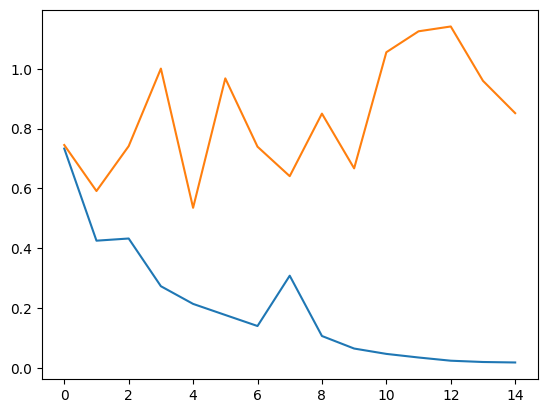

In [6]:
import matplotlib.pyplot as plt

plt.plot(history['loss'])
plt.plot(history['eval_loss'])
plt.show()

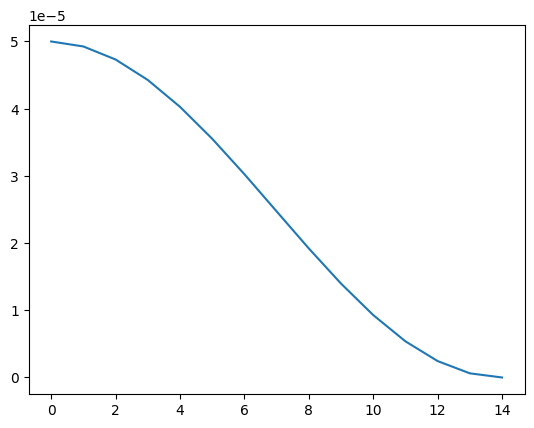

In [7]:
plt.plot(history['lr'])
plt.show()

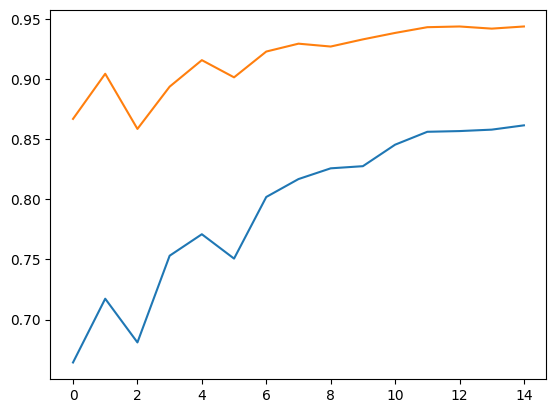

In [9]:
plt.plot(history['acc'])
plt.plot(history['relax_acc'])
plt.show()

In [10]:
cleandata_path = "D:\\GeoTKG\\cleandata\\normalise\\"
test = TemporalDataset(cleandata_path + "test.json")
test_loader = torch.utils.data.DataLoader(test, batch_size=BATCH_SIZE, shuffle=True, collate_fn=lambda b: collator(b, tokenizer))

model.eval()
test_loss = 0.0
decoded_preds, decoded_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        # keep a copy of labels for loss and for decoding ground truth
        labels_copy = batch["labels"].clone()
        batch = {k: v.to(device) for k, v in batch.items()}

        # loss
        out = model(**batch)
        test_loss += out.loss.item()

        # predictions
        gen_ids = model.generate(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            max_new_tokens=MAX_NEW_TOK,
            num_beams=4,
            early_stopping=True
        )
        decoded_preds.extend(tokenizer.batch_decode(gen_ids, skip_special_tokens=True))
        labels_copy[labels_copy == -100] = tokenizer.pad_token_id
        decoded_labels.extend(tokenizer.batch_decode(labels_copy, skip_special_tokens=True))

avg_test_loss = test_loss / max(1, len(test_loader))
metrics = compute_metrics(decoded_labels, decoded_preds)

In [11]:
avg_test_loss, metrics

(0.8435675533800167,
 {'accuracy strict': 0.8487124463519313,
  'accuracy relaxed': 0.9484978540772532})